# Data Understanding: Raw Online Retail Transactions

## Overview

This notebook profiles the original transaction files before any cleaning or feature derivation. The goal is to understand the raw schema, volume, missingness, anomalies, and business shape of the source data that will feed `02_Data_Cleaning.ipynb`.

## Analysis Objectives

1. **Raw Input Validation**: Confirm the two source CSV files exist and can be loaded consistently.
2. **Schema Understanding**: Review original columns, dtypes, and source-period coverage.
3. **Data Quality Profiling**: Inspect missing values, duplicates, cancellations, negative quantities, and basic anomalies.
4. **Business Shape Preview**: Summarize customers, invoices, countries, and products using only raw transaction fields.
5. **Temporal Coverage**: Check date coverage and monthly transaction patterns before cleaning.
6. **Cleaning Handoff**: Identify what must be standardized or derived in the next notebook.

## Raw Dataset Information

- **Source files**: `data/Year 2009-2010.csv` and `data/Year 2010-2011.csv`
- **Original columns**: `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, `Country`
- **Important constraint**: Derived fields such as `TotalValue`, `InvoiceType`, `ProductCategory`, `FirstPurchaseDate`, and cohort columns are not expected to exist yet.

## Phase A Input Contract

Notebook này phải chạy **trước** `02_Data_Cleaning.ipynb` và chỉ làm việc với dữ liệu thô.

- Đọc trực tiếp 2 file raw theo năm.
- Không phụ thuộc vào bất kỳ file trong `data/cleaned/`.
- Không giả định đã có các cột phát sinh sau cleaning.
- Kết quả của notebook này là hiểu dữ liệu nguồn và chuẩn bị checklist cho bước cleaning tiếp theo.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


def resolve_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "Notebook").exists():
            return candidate
        if (candidate / "404_Not_Found").exists():
            return candidate / "404_Not_Found"
    raise FileNotFoundError("Cannot resolve project root for the 404_Not_Found workspace.")


project_root = resolve_project_root(Path.cwd())
raw_dir = project_root / "data"
raw_files = {
    "2009-2010": raw_dir / "Year 2009-2010.csv",
    "2010-2011": raw_dir / "Year 2010-2011.csv",
}

missing_files = [str(path) for path in raw_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing raw dataset(s). Expected source files before cleaning:\n"
        + "\n".join(missing_files)
    )

print("Raw input config loaded.")
print(f"- Project root: {project_root}")
for label, path in raw_files.items():
    print(f"- Raw file {label}: {path}")
print(f"- Seed: {SEED}")

Raw input config loaded.
- Project root: d:\Data impact\404_Not_Found
- Raw file 2009-2010: d:\Data impact\404_Not_Found\data\Year 2009-2010.csv
- Raw file 2010-2011: d:\Data impact\404_Not_Found\data\Year 2010-2011.csv
- Seed: 42


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

print(f"Current date/time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Current date/time: 2026-04-25 19:17:32


In [4]:
print("=== RAW DATA LOADING ===")

frames = []
for period, data_path in raw_files.items():
    frame = pd.read_csv(
        data_path,
        parse_dates=["InvoiceDate"],
        dtype={"Invoice": "string", "StockCode": "string", "Customer ID": "string"},
        encoding="cp1252",
    )
    frame["SourcePeriod"] = period
    frames.append(frame)
    print(f"- {period}: {len(frame):,} rows loaded from {data_path.name}")

df_raw = pd.concat(frames, ignore_index=True)
df_raw["LineValue"] = df_raw["Quantity"] * df_raw["Price"]

df_sales_raw = df_raw[df_raw["Quantity"] > 0].copy()
df_returns_raw = df_raw[df_raw["Quantity"] < 0].copy()
df_cancelled_raw = df_raw[df_raw["Invoice"].fillna("").str.startswith("C")].copy()

print(f"\nCombined shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print(f"Date range: {df_raw['InvoiceDate'].min()} to {df_raw['InvoiceDate'].max()}")
print(f"Sales rows: {len(df_sales_raw):,}")
print(f"Returns rows: {len(df_returns_raw):,}")
print(f"Cancelled invoice rows: {len(df_cancelled_raw):,}")

print("\nFirst 5 raw rows:")
display(df_raw.head())

=== RAW DATA LOADING ===
- 2009-2010: 525,461 rows loaded from Year 2009-2010.csv
- 2010-2011: 541,910 rows loaded from Year 2010-2011.csv

Combined shape: 1,067,371 rows x 10 columns
Memory usage: 398.52 MB
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Sales rows: 1,044,421
Returns rows: 22,950
Cancelled invoice rows: 19,494

First 5 raw rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourcePeriod,LineValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-2010,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-2010,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-2010,30.0


In [5]:
print("=== RAW SCHEMA AND DATA QUALITY ===")

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

missing_summary = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda table: table["missing_count"] / len(df_raw) * 100)
    .sort_values("missing_count", ascending=False)
    .reset_index()
    .rename(columns={"index": "column"})
)

print("\nMissing values summary:")
display(missing_summary)

duplicate_rows = int(df_raw.duplicated().sum())
duplicate_invoice_stock = int(df_raw.duplicated(subset=["Invoice", "StockCode", "InvoiceDate", "Quantity", "Price"]).sum())
missing_customer_rows = int(df_raw["Customer ID"].isna().sum())
missing_description_rows = int(df_raw["Description"].isna().sum())
negative_quantity_rows = int((df_raw["Quantity"] < 0).sum())
non_positive_price_rows = int((df_raw["Price"] <= 0).sum())

quality_checks = pd.DataFrame(
    [
        {"check": "Duplicate full rows", "value": duplicate_rows},
        {"check": "Duplicate invoice-stock-date-price rows", "value": duplicate_invoice_stock},
        {"check": "Rows missing Customer ID", "value": missing_customer_rows},
        {"check": "Rows missing Description", "value": missing_description_rows},
        {"check": "Rows with negative Quantity", "value": negative_quantity_rows},
        {"check": "Rows with Price <= 0", "value": non_positive_price_rows},
    ]
)

print("\nRaw quality checks:")
display(quality_checks)

=== RAW SCHEMA AND DATA QUALITY ===

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SourcePeriod', 'LineValue']

Data types:
Invoice         string[python]
StockCode       string[python]
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
Customer ID     string[python]
Country                 object
SourcePeriod            object
LineValue              float64
dtype: object

Missing values summary:


,column,missing_count,missing_pct
0,Customer ID,243007,22.766873
1,Description,4382,0.410541
2,StockCode,0,0.000000
3,Invoice,0,0.000000
4,InvoiceDate,0,0.000000
5,Quantity,0,0.000000
6,Price,0,0.000000
7,Country,0,0.000000
8,SourcePeriod,0,0.000000
9,LineValue,0,0.000000



Raw quality checks:


,check,value
0,Duplicate full rows,12133
1,Duplicate invoice-stock-date-price rows,34337
2,Rows missing Customer ID,243007
3,Rows missing Description,4382
4,Rows with negative Quantity,22950
5,Rows with Price <= 0,6207


In [6]:
print("=== RAW BUSINESS SHAPE PREVIEW ===")

overview = pd.DataFrame(
    [
        {"metric": "Unique invoices", "value": df_raw["Invoice"].nunique()},
        {"metric": "Unique products", "value": df_raw["StockCode"].nunique()},
        {"metric": "Unique customers (non-null)", "value": df_raw["Customer ID"].nunique(dropna=True)},
        {"metric": "Countries", "value": df_raw["Country"].nunique()},
        {"metric": "Gross positive line value", "value": df_sales_raw["LineValue"].sum()},
        {"metric": "Absolute return line value", "value": abs(df_returns_raw["LineValue"].sum())},
    ]
)

display(overview)

top_countries = (
    df_raw.groupby("Country")
    .agg(
        row_count=("Invoice", "size"),
        unique_customers=("Customer ID", lambda values: values.nunique(dropna=True)),
        unique_invoices=("Invoice", "nunique"),
    )
    .sort_values("row_count", ascending=False)
    .head(10)
    .reset_index()
)

top_products = (
    df_sales_raw.groupby(["StockCode", "Description"], dropna=False)
    .agg(
        quantity_sold=("Quantity", "sum"),
        sales_rows=("Invoice", "size"),
        sales_value=("LineValue", "sum"),
    )
    .sort_values("sales_value", ascending=False)
    .head(10)
    .reset_index()
)

customer_invoice_counts = (
    df_raw.dropna(subset=["Customer ID"])
    .groupby("Customer ID")
    .agg(
        invoice_count=("Invoice", "nunique"),
        row_count=("Invoice", "size"),
    )
    .reset_index()
)

print("Top 10 countries by raw row count:")
display(top_countries)

print("Top 10 products by raw positive sales value:")
display(top_products)

print("Customer invoice count summary:")
display(customer_invoice_counts[["invoice_count", "row_count"]].describe())

=== RAW BUSINESS SHAPE PREVIEW ===


,metric,value
0,Unique invoices,5.362800e+04
1,Unique products,5.305000e+03
2,Unique customers (non-null),5.942000e+03
3,Countries,4.300000e+01
4,Gross positive line value,2.081429e+07
5,Absolute return line value,1.527041e+06


Top 10 countries by raw row count:


,Country,row_count,unique_customers,unique_invoices
0,United Kingdom,981330,5410,49108
1,EIRE,17866,5,806
2,Germany,17624,107,1095
3,France,14330,95,746
4,Netherlands,5140,23,250
5,Spain,3811,41,188
6,Switzerland,3189,22,123
7,Belgium,3123,29,183
8,Portugal,2620,24,124
9,Australia,1913,15,117


Top 10 products by raw positive sales value:


,StockCode,Description,quantity_sold,sales_rows,sales_value
0,22423,REGENCY CAKESTAND 3 TIER,27594,4065,344563.25
1,M,Manual,10058,884,341089.85
2,DOT,DOTCOM POSTAGE,1441,1441,322657.48
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96091,5682,262931.16
4,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,168469.60
5,47566,PARTY BUNTING,28395,2742,149187.05
6,85099B,JUMBO BAG RED RETROSPOT,78866,3370,148823.92
7,84879,ASSORTED COLOUR BIRD ORNAMENT,81817,2939,132187.92
8,POST,POSTAGE,5461,1886,127597.42
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,36581,2198,123141.54


Customer invoice count summary:


,invoice_count,row_count
count,5942.000000,5942.000000
mean,7.552339,138.735106
std,15.972262,359.689585
min,1.000000,1.000000
25%,2.000000,21.000000
50%,4.000000,53.000000
75%,8.000000,144.000000
max,510.000000,13097.000000


=== RAW DISTRIBUTIONS AND TIME COVERAGE ===


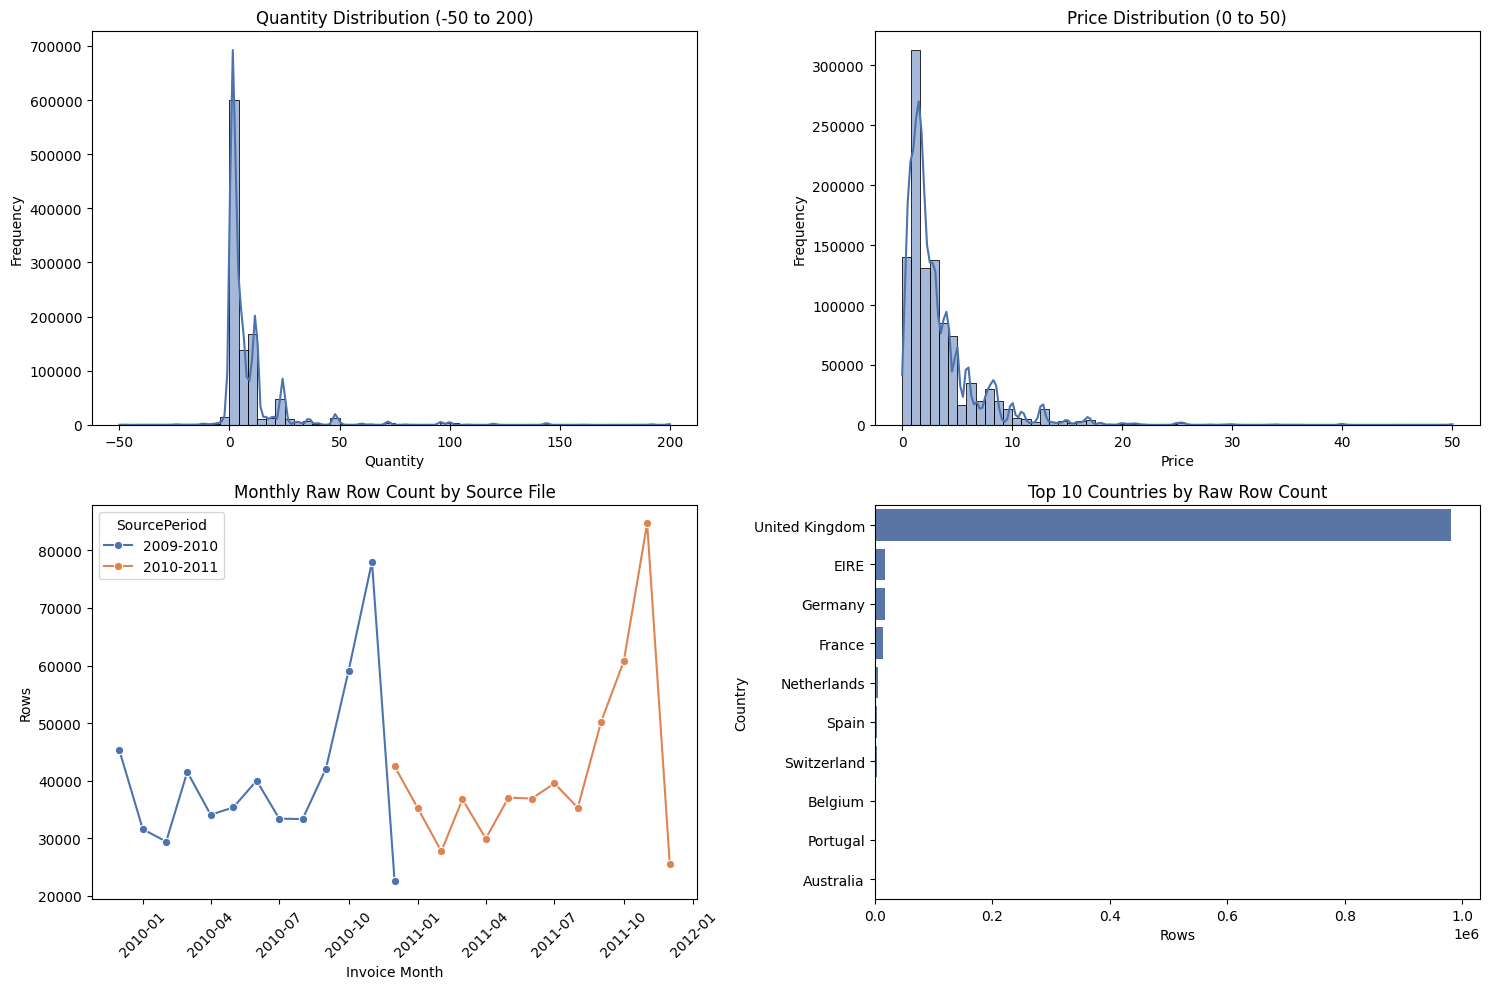

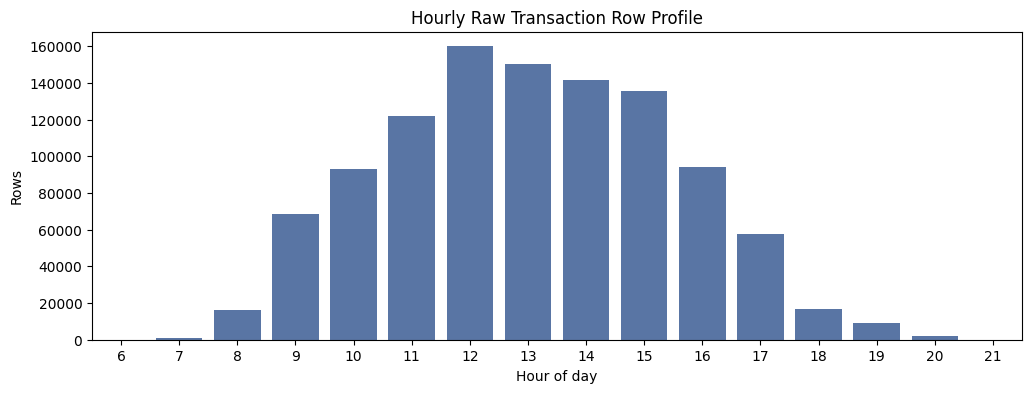

In [7]:
print("=== RAW DISTRIBUTIONS AND TIME COVERAGE ===")

plot_df = df_raw.copy()
plot_df["InvoiceMonth"] = plot_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

monthly_rows = (
    plot_df.groupby(["InvoiceMonth", "SourcePeriod"])
    .size()
    .reset_index(name="row_count")
)

top_country_counts = plot_df["Country"].value_counts().head(10)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
quantity_window = plot_df.loc[plot_df["Quantity"].between(-50, 200), "Quantity"]
sns.histplot(quantity_window, bins=60, kde=True)
plt.title("Quantity Distribution (-50 to 200)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 2)
price_window = plot_df.loc[plot_df["Price"].between(0, 50), "Price"]
sns.histplot(price_window, bins=60, kde=True)
plt.title("Price Distribution (0 to 50)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.subplot(2, 2, 3)
sns.lineplot(data=monthly_rows, x="InvoiceMonth", y="row_count", hue="SourcePeriod", marker="o")
plt.title("Monthly Raw Row Count by Source File")
plt.xlabel("Invoice Month")
plt.ylabel("Rows")
plt.xticks(rotation=45)

plt.subplot(2, 2, 4)
sns.barplot(x=top_country_counts.values, y=top_country_counts.index)
plt.title("Top 10 Countries by Raw Row Count")
plt.xlabel("Rows")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

hourly_profile = plot_df.groupby(plot_df["InvoiceDate"].dt.hour).size().reset_index(name="row_count")
hourly_profile.columns = ["Hour", "row_count"]

plt.figure(figsize=(12, 4))
sns.barplot(data=hourly_profile, x="Hour", y="row_count")
plt.title("Hourly Raw Transaction Row Profile")
plt.xlabel("Hour of day")
plt.ylabel("Rows")
plt.show()

In [8]:
print("=== RAW DATA TAKEAWAYS ===")

cancelled_invoice_share = df_cancelled_raw["Invoice"].nunique() / df_raw["Invoice"].nunique() * 100
missing_customer_share = df_raw["Customer ID"].isna().mean() * 100
negative_quantity_share = (df_raw["Quantity"] < 0).mean() * 100

print(f"1. Raw source consists of {len(df_raw):,} transaction rows across {len(raw_files)} yearly files.")
print(f"2. Missing Customer ID is material at {missing_customer_share:.2f}% of rows and must be handled in cleaning.")
print(f"3. Negative quantities appear in {negative_quantity_share:.2f}% of rows, indicating returns or reversals.")
print(f"4. Cancelled invoices represent {cancelled_invoice_share:.2f}% of unique invoices based on the raw invoice prefix rule.")
print("5. Derived columns used in downstream EDA do not exist yet and should only be created in 02_Data_Cleaning.ipynb.")

print("\n=== HANDOFF TO 02_DATA_CLEANING ===")
print("Next notebook should:")
print("- Standardize Customer ID handling and decide the drop/impute policy.")
print("- Clean descriptions and invalid prices.")
print("- Separate sales from returns in a controlled way.")
print("- Create derived fields such as TotalValue, InvoiceType, ProductCategory, FirstPurchaseDate, and cohort features.")
print("- Save cleaned outputs to data/cleaned/ for the downstream EDA and modeling notebooks.")

=== RAW DATA TAKEAWAYS ===
1. Raw source consists of 1,067,371 transaction rows across 2 yearly files.
2. Missing Customer ID is material at 22.77% of rows and must be handled in cleaning.
3. Negative quantities appear in 2.15% of rows, indicating returns or reversals.
4. Cancelled invoices represent 15.46% of unique invoices based on the raw invoice prefix rule.
5. Derived columns used in downstream EDA do not exist yet and should only be created in 02_Data_Cleaning.ipynb.

=== HANDOFF TO 02_DATA_CLEANING ===
Next notebook should:
- Standardize Customer ID handling and decide the drop/impute policy.
- Clean descriptions and invalid prices.
- Separate sales from returns in a controlled way.
- Create derived fields such as TotalValue, InvoiceType, ProductCategory, FirstPurchaseDate, and cohort features.
- Save cleaned outputs to data/cleaned/ for the downstream EDA and modeling notebooks.
